In [1]:
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import copy

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

from sklearn.preprocessing import StandardScaler

C:\Users\apple\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean

class Model(nn.Module):
    """
    Decomposition-Linear
    """
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len

        # Decompsition Kernel Size
        kernel_size = 25
        self.decompsition = series_decomp(kernel_size)
        self.individual = configs.individual
        self.channels = configs.enc_in

        if self.individual:
            self.Linear_Seasonal = nn.ModuleList()
            self.Linear_Trend = nn.ModuleList()
            
            for i in range(self.channels):
                self.Linear_Seasonal.append(nn.Linear(self.seq_len,self.pred_len))
                self.Linear_Trend.append(nn.Linear(self.seq_len,self.pred_len))

                # Use this two lines if you want to visualize the weights
                # self.Linear_Seasonal[i].weight = nn.Parameter((1/self.seq_len)*torch.ones([self.pred_len,self.seq_len]))
                # self.Linear_Trend[i].weight = nn.Parameter((1/self.seq_len)*torch.ones([self.pred_len,self.seq_len]))
        else:
            self.Linear_Seasonal = nn.Linear(self.seq_len,self.pred_len)
            self.Linear_Trend = nn.Linear(self.seq_len,self.pred_len)
            
            # Use this two lines if you want to visualize the weights
            # self.Linear_Seasonal.weight = nn.Parameter((1/self.seq_len)*torch.ones([self.pred_len,self.seq_len]))
            # self.Linear_Trend.weight = nn.Parameter((1/self.seq_len)*torch.ones([self.pred_len,self.seq_len]))

    def forward(self, x):
        # x: [Batch, Input length, Channel]
        seasonal_init, trend_init = self.decompsition(x)
        seasonal_init, trend_init = seasonal_init.permute(0,2,1), trend_init.permute(0,2,1)
        if self.individual:
            seasonal_output = torch.zeros([seasonal_init.size(0),seasonal_init.size(1),self.pred_len],dtype=seasonal_init.dtype).to(seasonal_init.device)
            trend_output = torch.zeros([trend_init.size(0),trend_init.size(1),self.pred_len],dtype=trend_init.dtype).to(trend_init.device)
            for i in range(self.channels):
                seasonal_output[:,i,:] = self.Linear_Seasonal[i](seasonal_init[:,i,:])
                trend_output[:,i,:] = self.Linear_Trend[i](trend_init[:,i,:])
        else:
            seasonal_output = self.Linear_Seasonal(seasonal_init)
            trend_output = self.Linear_Trend(trend_init)

        x = seasonal_output + trend_output
        return x.permute(0,2,1) # to [Batch, Output length, Channel]
    
class Config:
    seq_len = 96
    pred_len = 24

    enc_in = 15
    individual = False

In [38]:
feature_cols = [
    "temp",
    "rainfall",
    "windspd",
    "windspd_max",
    "wind_d",
    "GHI",
    "DNI",
    "DHI",
    "UVA",
    "ClearSkyGHI",
    "CSI",
    "hour_sin",
    "hour_cos",
    "day_year_sin",
    "day_year_cos"
]

target_col = "UVI"

In [37]:
train_df = pd.read_csv(
    "train_dataset_v2.csv",
    index_col=0
)

val_df = pd.read_csv(
    "val_dataset_v2.csv",
    index_col=0
)

test_df = pd.read_csv(
    "test_dataset_v2.csv",
    index_col=0
)

In [36]:
train_y = y_scaler.fit_transform(
    train_df[["UVI"]]
)

val_y = y_scaler.transform(
    val_df[["UVI"]]
)

test_y = y_scaler.transform(
    test_df[["UVI"]]
)

In [35]:
class WeatherTimeSeriesDataset(Dataset):

    def __init__(
        self,
        data_matrix,
        target_matrix,
        seq_len=96,
        pred_len=24
    ):

        self.seq_len = seq_len
        self.pred_len = pred_len

        self.valid_length = (
            len(data_matrix)
            - seq_len
            - pred_len
            + 1
        )

        self.x = torch.FloatTensor(data_matrix)
        self.y = torch.FloatTensor(target_matrix)

    def __len__(self):
        return self.valid_length

    def __getitem__(self, idx):

        seq_x = self.x[
            idx : idx+self.seq_len
        ]

        seq_y = self.y[
            idx+self.seq_len :
            idx+self.seq_len+self.pred_len,
            0
        ]

        return seq_x, seq_y

In [33]:
class UVIDLinear(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = Model(Config())

        self.head = nn.Linear(
            Config.enc_in,
            1
        )

    def forward(self, x):

        x = self.backbone(x)

        # [B,24,15]
        x = self.head(x)

        # [B,24,1]
        x = x.squeeze(-1)

        # [B,24]
        return x

In [8]:
def train_model(model, train_loader, val_loader, epochs=50, device='cuda',
                lr=1e-3, weight_decay=1e-4, patience=7, warmup_epochs=5):
    model = model.to(device)
    criterion = nn.SmoothL1Loss(beta=1.0)      # Huber Loss，beta 可改为 2.0
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ---- 学习率调度：warmup + 余弦退火 ----
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # 线性增长
            return (epoch + 1) / warmup_epochs
        else:
            # 余弦退火从 warmup 结束到最终
            progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
            return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = LambdaLR(optimizer, lr_lambda)

    best_val_loss = float('inf')
    counter = 0
    best_model_weights = None

    print(f"🚀 开始训练 (warmup={warmup_epochs} epochs, patience={patience})")

    for epoch in range(epochs):
        # ---------- 训练 ----------
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)                     # (batch, pred_len)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # 梯度裁剪（注意力模型建议 2.0）
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

            train_loss += loss.item() * batch_x.size(0)
        train_loss /= len(train_loader.dataset)

        # ---------- 验证 ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
        val_loss /= len(val_loader.dataset)

        # 更新学习率
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.2e}")

        # 早停机制
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"⏹️  早停触发（{patience} epoch 无改善），停止训练")
                break

    # 恢复最佳权重
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
    print(f"✅ 训练完成，最佳验证损失: {best_val_loss:.4f}")
    return model

In [9]:
import pandas as pd

train_df = pd.read_csv("train_dataset.csv", index_col=0)
val_df   = pd.read_csv("val_dataset.csv", index_col=0)
test_df  = pd.read_csv("test_dataset.csv", index_col=0)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(13123, 16)
(2208, 16)
(2141, 16)


In [25]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[feature_cols])
val_x   = x_scaler.transform(val_df[feature_cols])
test_x  = x_scaler.transform(test_df[feature_cols])

train_y = y_scaler.fit_transform(train_df[[target_col]])
val_y   = y_scaler.transform(val_df[[target_col]])
test_y  = y_scaler.transform(test_df[[target_col]])

train_dataset = WeatherTimeSeriesDataset(
    train_x,
    train_y,
    seq_len=96,
    pred_len=24
)

val_dataset = WeatherTimeSeriesDataset(
    val_x,
    val_y,
    seq_len=96,
    pred_len=24
)

test_dataset = WeatherTimeSeriesDataset(
    test_x,
    test_y,
    seq_len=96,
    pred_len=24
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

13004
2089
2022


In [26]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([32, 96, 15])
torch.Size([32, 24])


In [41]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(
    train_df[feature_cols]
)

val_x = x_scaler.transform(
    val_df[feature_cols]
)

test_x = x_scaler.transform(
    test_df[feature_cols]
)

train_y = y_scaler.fit_transform(
    train_df[[target_col]]
)

val_y = y_scaler.transform(
    val_df[[target_col]]
)

test_y = y_scaler.transform(
    test_df[[target_col]]
)

In [47]:
model = UVIDLinear()

model = train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    device='cpu'
)

🚀 开始训练 (warmup=5 epochs, patience=7)
Epoch 01/50 | Train Loss: 0.2600 | Val Loss: 0.2457 | LR: 4.00e-04
Epoch 02/50 | Train Loss: 0.1334 | Val Loss: 0.1769 | LR: 6.00e-04
Epoch 03/50 | Train Loss: 0.1095 | Val Loss: 0.1683 | LR: 8.00e-04
Epoch 04/50 | Train Loss: 0.1012 | Val Loss: 0.1697 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 0.0971 | Val Loss: 0.1630 | LR: 1.00e-03
Epoch 06/50 | Train Loss: 0.0956 | Val Loss: 0.1962 | LR: 9.99e-04
Epoch 07/50 | Train Loss: 0.1031 | Val Loss: 0.1682 | LR: 9.95e-04
Epoch 08/50 | Train Loss: 0.1030 | Val Loss: 0.1642 | LR: 9.89e-04
Epoch 09/50 | Train Loss: 0.1000 | Val Loss: 0.1666 | LR: 9.81e-04
Epoch 10/50 | Train Loss: 0.0988 | Val Loss: 0.1654 | LR: 9.70e-04
Epoch 11/50 | Train Loss: 0.0977 | Val Loss: 0.1644 | LR: 9.57e-04
Epoch 12/50 | Train Loss: 0.0968 | Val Loss: 0.1626 | LR: 9.41e-04
Epoch 13/50 | Train Loss: 0.0960 | Val Loss: 0.1610 | LR: 9.24e-04
Epoch 14/50 | Train Loss: 0.0951 | Val Loss: 0.1599 | LR: 9.05e-04
Epoch 15/50 | Train Loss:

In [30]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(
    train_df[feature_cols]
)

val_x = x_scaler.transform(
    val_df[feature_cols]
)

test_x = x_scaler.transform(
    test_df[feature_cols]
)

train_y = y_scaler.fit_transform(
    train_df[[target_col]]
)

val_y = y_scaler.transform(
    val_df[[target_col]]
)

test_y = y_scaler.transform(
    test_df[[target_col]]
)

In [46]:
print("Train X NaN:", np.isnan(train_x).sum())
print("Val X NaN:", np.isnan(val_x).sum())
print("Test X NaN:", np.isnan(test_x).sum())

print("Train Y NaN:", np.isnan(train_y).sum())
print("Val Y NaN:", np.isnan(val_y).sum())
print("Test Y NaN:", np.isnan(test_y).sum())

print("Train X Inf:", np.isinf(train_x).sum())
print("Train Y Inf:", np.isinf(train_y).sum())

Train X NaN: 0
Val X NaN: 0
Test X NaN: 0
Train Y NaN: 0
Val Y NaN: 0
Test Y NaN: 0
Train X Inf: 0
Train Y Inf: 0


In [45]:
train_dataset = WeatherTimeSeriesDataset(
    train_x,
    train_y,
    seq_len=96,
    pred_len=24
)

val_dataset = WeatherTimeSeriesDataset(
    val_x,
    val_y,
    seq_len=96,
    pred_len=24
)

test_dataset = WeatherTimeSeriesDataset(
    test_x,
    test_y,
    seq_len=96,
    pred_len=24
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [48]:
import torch
import torch.nn as nn

# 测试集评估函数
@torch.no_grad()
def evaluate(model, data_loader, device='cpu'):
    """
    返回模型在给定 DataLoader 上的平均 Huber Loss（beta=1.0）
    """
    model.eval()
    criterion = nn.SmoothL1Loss(beta=1.0)
    total_loss = 0.0
    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        total_loss += loss.item() * batch_x.size(0)
    return total_loss / len(data_loader.dataset)

In [49]:
test_loss = evaluate(model, test_loader, device="cpu")
print(f"📊 测试集 Huber Loss: {test_loss:.4f}")

📊 测试集 Huber Loss: 0.0513


In [50]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

@torch.no_grad()
def predict_and_evaluate(model, data_loader, y_scaler, device='cpu'):
    """
    输入：
        model: 已训练的 DLinear 模型
        data_loader: 测试集 DataLoader
        y_scaler: 用于反标准化的 StandardScaler
        device: 'cpu' 或 'cuda'
    返回：
        dict: { 'MAE', 'RMSE', 'R2' }，以及反标准化预测和真实值
    """
    model.eval()
    model.to(device)
    
    preds = []
    trues = []

    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        out = model(batch_x)
        preds.append(out)
        trues.append(batch_y)

    # 拼接 batch
    preds = torch.cat(preds, dim=0).cpu().numpy()
    trues = torch.cat(trues, dim=0).cpu().numpy()

    # 反标准化
    preds_inv = y_scaler.inverse_transform(preds)
    trues_inv = y_scaler.inverse_transform(trues)

    # 计算指标
    mae = mean_absolute_error(trues_inv, preds_inv)
    rmse = mean_squared_error(trues_inv, preds_inv, squared=False)
    r2 = r2_score(trues_inv, preds_inv)

    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

    return metrics, preds_inv, trues_inv

metrics, preds_inv, trues_inv = predict_and_evaluate(
    model=model,
    data_loader=test_loader,
    y_scaler=y_scaler,
    device='cpu'  # 如果支持GPU改成 'cuda'
)

print("📊 DLinear 测试集指标:")
print(f"MAE  = {metrics['MAE']:.4f}")
print(f"RMSE = {metrics['RMSE']:.4f}")
print(f"R²   = {metrics['R2']:.4f}")

import pandas as pd

df_results = pd.DataFrame({
    'True_UVI': trues_inv.flatten(),
    'Pred_UVI': preds_inv.flatten()
}, index=test_df.index[96:])  # 注意滑动窗口第一个96小时不能预测

df_results.to_csv("DLinear_test_predictions.csv")
print("✅ 预测结果已保存：DLinear_test_predictions.csv")

📊 DLinear 测试集指标:
MAE  = 0.4311
RMSE = 0.7727
R²   = 0.8043


ValueError: Length of values (48528) does not match length of index (2045)

In [51]:
time_index = []

for i in range(len(preds_inv)):
    start = test_df.index[i + 96]
    rng = pd.date_range(
        start=start,
        periods=24,
        freq='H'
    )
    time_index.extend(rng)

len(time_index)

C:\Users\apple\AppData\Local\Temp\ipykernel_1452\59912197.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rng = pd.date_range(


48528

In [52]:
export_df = pd.DataFrame({
    "time": time_index,
    "True_UVI": trues_inv.flatten(),
    "Dlinear_Pred": preds_inv.flatten()
})

export_df.to_csv(
    "Dlinear_with_time.csv",
    index=False
)

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

step_metrics = []

for i in range(24):

    mae = mean_absolute_error(
        trues_inv[:, i],
        preds_inv[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            trues_inv[:, i],
            preds_inv[:, i]
        )
    )

    step_metrics.append(
        [i+1, mae, rmse]
    )

step_metrics = pd.DataFrame(
    step_metrics,
    columns=["Horizon","MAE","RMSE"]
)

print(step_metrics)

    Horizon       MAE      RMSE
0         1  0.388986  0.582537
1         2  0.412809  0.660579
2         3  0.429856  0.718269
3         4  0.437214  0.749597
4         5  0.438717  0.763543
5         6  0.441831  0.768828
6         7  0.442364  0.770136
7         8  0.443298  0.770397
8         9  0.444459  0.771081
9        10  0.444785  0.770756
10       11  0.446733  0.771380
11       12  0.445792  0.771743
12       13  0.447422  0.771119
13       14  0.445412  0.770144
14       15  0.445368  0.770082
15       16  0.444972  0.770527
16       17  0.445397  0.771035
17       18  0.444757  0.771586
18       19  0.444289  0.770887
19       20  0.444744  0.770817
20       21  0.443347  0.770121
21       22  0.444085  0.770907
22       23  0.439978  0.772267
23       24  0.439896  0.773228


In [51]:
step_metrics.to_csv(
    "DLinear_step_metrics.csv",
    index=False
)

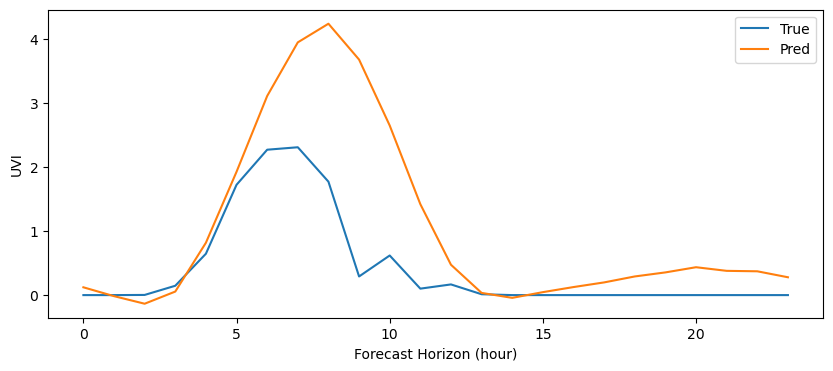

In [52]:
import matplotlib.pyplot as plt

sample = 100

plt.figure(figsize=(10,4))

plt.plot(
    trues_inv[sample],
    label="True"
)

plt.plot(
    preds_inv[sample],
    label="Pred"
)

plt.xlabel("Forecast Horizon (hour)")
plt.ylabel("UVI")
plt.legend()
plt.show()